In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import precision_recall_curve, auc
from sklearn.manifold import TSNE
from tensorflow.keras.models import load_model, Model


In [2]:
tf.keras.backend.clear_session()

In [3]:
# --- 1. DIRECTORIES ---
FOLDS_DIR = r"C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\data\imgData\prepImg\Folds"
MODEL_DIR = r"C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\infant-growth-monitoring-system\mlModels\autisumDetect\sector1\Best_Models"

In [4]:
# --- PREPROCESSING (CRITICAL: Must match training) ---
def process_eval_data(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    
    # VGG-Face Preprocessing
    img = img[..., ::-1] # RGB to BGR
    mean = [93.5940, 104.7624, 129.1863]
    img = img - mean
    
    # Logic: Autistic=1, Non_Autistic=0
    target_label = 1.0 - tf.cast(label, tf.float32)
    return img, target_label

# Storage for results
fold_accuracies = []
all_true_labels = []
all_pred_labels = []

print("Starting Step 1 & 2: Aggregated Evaluation...")

Starting Step 1 & 2: Aggregated Evaluation...


In [5]:
for fold_id in range(1, 6):
    print(f"\n--- Processing Fold {fold_id} ---")
    
    # 1. Load Fold Data
    val_paths = np.load(os.path.join(FOLDS_DIR, f'fold_{fold_id}_val_paths.npy'), allow_pickle=True)
    val_labels = np.load(os.path.join(FOLDS_DIR, f'fold_{fold_id}_val_labels.npy'), allow_pickle=True)
    
    val_ds = (tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
              .map(process_eval_data)
              .batch(8))
    
    # 2. Load the Saved Model
    model_path = os.path.join(MODEL_DIR, f'fold_{fold_id}_best.h5')
    model = load_model(model_path, compile=False)
    
    # 3. Get Predictions
    y_true_fold = []
    y_pred_fold = []
    
    for imgs, labels in val_ds:
        # Prediction comes from 'classification_output'
        preds, _ = model.predict(imgs, verbose=0)
        y_pred_fold.extend(preds.flatten())
        y_true_fold.extend(labels.numpy().flatten())
    
    # Convert probabilities to 0 or 1
    y_pred_binary = (np.array(y_pred_fold) > 0.5).astype(int)
    y_true_binary = np.array(y_true_fold).astype(int)
    
    # Calculate Accuracy for this fold
    acc = np.mean(y_true_binary == y_pred_binary)
    fold_accuracies.append(acc)
    
    # Aggregate for Step 2
    all_true_labels.extend(y_true_binary)
    all_pred_labels.extend(y_pred_binary)
    
    print(f"Fold {fold_id} Accuracy: {acc:.4f}")


--- Processing Fold 1 ---
Fold 1 Accuracy: 0.7163

--- Processing Fold 2 ---
Fold 2 Accuracy: 0.7433

--- Processing Fold 3 ---
Fold 3 Accuracy: 0.7560

--- Processing Fold 4 ---
Fold 4 Accuracy: 0.7716

--- Processing Fold 5 ---
Fold 5 Accuracy: 0.7135


In [6]:
# --- STEP 1 RESULTS (Reliability) ---
mean_acc = np.mean(fold_accuracies)
std_acc = np.std(fold_accuracies)

print("\n" + "="*40)
print(f"FINAL MEAN ACCURACY: {mean_acc:.4f}")
print(f"STANDARD DEVIATION:  {std_acc:.4f}")
print("="*40)


FINAL MEAN ACCURACY: 0.7401
STANDARD DEVIATION:  0.0225


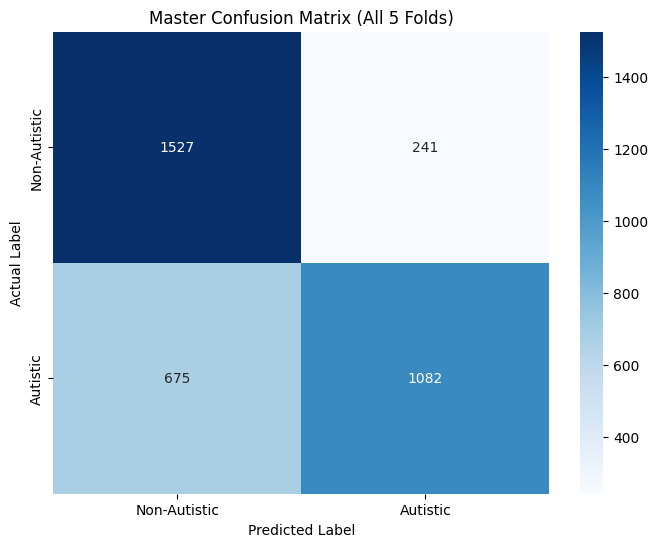


--- GLOBAL CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

Non-Autistic       0.69      0.86      0.77      1768
    Autistic       0.82      0.62      0.70      1757

    accuracy                           0.74      3525
   macro avg       0.76      0.74      0.74      3525
weighted avg       0.76      0.74      0.74      3525



In [7]:
# --- STEP 2 RESULTS (Confusion Matrix) ---
cm = confusion_matrix(all_true_labels, all_pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Autistic', 'Autistic'], 
            yticklabels=['Non-Autistic', 'Autistic'])
plt.title('Master Confusion Matrix (All 5 Folds)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print("\n--- GLOBAL CLASSIFICATION REPORT ---")
print(classification_report(all_true_labels, all_pred_labels, target_names=['Non-Autistic', 'Autistic']))

In [10]:
# --- 2. LOAD DATA FROM DISK ---
print("Loading Permanent Test Set...")
test_paths = np.load(os.path.join(FOLDS_DIR, 'permanent_test_paths.npy'), allow_pickle=True)
test_labels = np.load(os.path.join(FOLDS_DIR, 'permanent_test_labels.npy'), allow_pickle=True)

test_ds = (tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
          .map(process_eval_data)
          .batch(4)) # Reduced batch size from 8 to 4 to save memory

# --- 3. LOAD THE BEST MODEL (Fold 4 was the highest) ---
best_model_path = os.path.join(MODEL_DIR, 'fold_4_best.h5') 
print(f"Loading Model: {best_model_path}")

# Load the model - compile=False is faster and uses less memory for inference
best_model = load_model(best_model_path, compile=False)

# --- 4. INFERENCE ---
y_true_test = []
y_pred_test = []

print("Running Inference on Blind Test Set...")
for imgs, labels in test_ds:
    # Use model.predict_on_batch for slightly better memory handling during loops
    preds, _ = best_model.predict(imgs, verbose=0)
    y_pred_test.extend(preds.flatten())
    y_true_test.extend(labels.numpy().flatten())

# Convert to binary
y_pred_test_binary = (np.array(y_pred_test) > 0.5).astype(int)
y_true_test_binary = np.array(y_true_test).astype(int)

# --- 5. VISUALIZE ---
test_acc = np.mean(y_true_test_binary == y_pred_test_binary)
print(f"\nFINAL BLIND TEST ACCURACY: {test_acc:.4f}")
print("\n" + classification_report(y_true_test_binary, y_pred_test_binary, target_names=['Non-Autistic', 'Autistic']))

Loading Permanent Test Set...
Loading Model: C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\infant-growth-monitoring-system\mlModels\autisumDetect\sector1\Best_Models\fold_4_best.h5
Running Inference on Blind Test Set...

FINAL BLIND TEST ACCURACY: 0.7602

              precision    recall  f1-score   support

Non-Autistic       0.70      0.93      0.80       197
    Autistic       0.89      0.59      0.71       195

    accuracy                           0.76       392
   macro avg       0.79      0.76      0.75       392
weighted avg       0.79      0.76      0.75       392



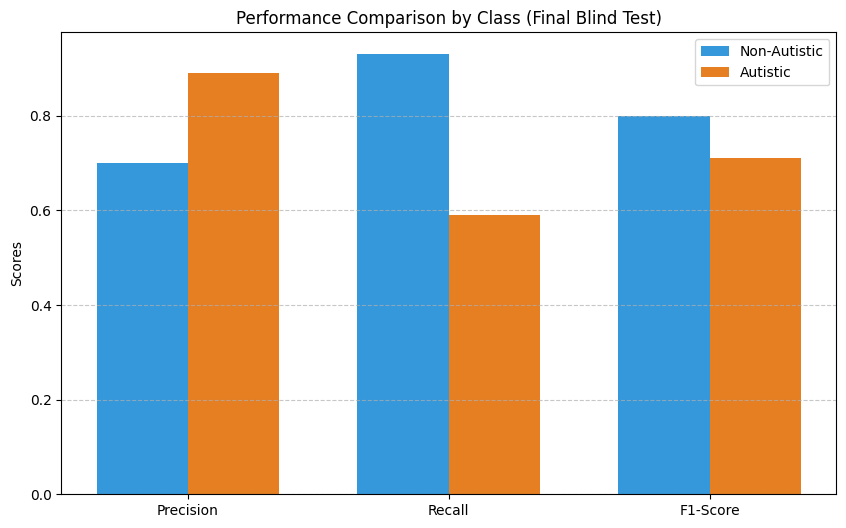

In [11]:
metrics = ['Precision', 'Recall', 'F1-Score']
non_asd = [0.70, 0.93, 0.80]
asd = [0.89, 0.59, 0.71]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, non_asd, width, label='Non-Autistic', color='#3498db')
rects2 = ax.bar(x + width/2, asd, width, label='Autistic', color='#e67e22')

ax.set_ylabel('Scores')
ax.set_title('Performance Comparison by Class (Final Blind Test)')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Analyzing Thresholds for Fold 4...
 Threshold  True Positives (ASD)  False Negatives (Missed)  Precision (ASD)  Recall (ASD)  F2-Score
      0.10                   155                        40            0.764         0.795     0.788
      0.15                   146                        49            0.781         0.749     0.755
      0.20                   140                        55            0.782         0.718     0.730
      0.25                   137                        58            0.811         0.703     0.722
      0.30                   128                        67            0.826         0.656     0.684
      0.35                   122                        73            0.841         0.626     0.659
      0.40                   118                        77            0.861         0.605     0.643
      0.45                   117                        78            0.886         0.600     0.641
      0.50                   115                        80       